In [1]:
# 1 — Two-year call base: deep-sea container calls, wait computed from timestamps
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()
calls["wait_h"] = (calls["ts_berth"] - calls["ts_arrival"]).dt.total_seconds() / 3600
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")

print(f"Container calls: {len(calls):,}", calls["navigation"].value_counts().to_dict())

lc = calls[calls["navigation"] == "Longo Curso"].copy()
year_start = pd.to_datetime(lc["year"].astype(str) + "-01-01")
checks = {
    "missing arrival or berth time": lc["wait_h"].isna(),
    "negative wait": lc["wait_h"] < 0,
    "wait above 14 days": lc["wait_h"] > 14 * 24,
    "arrival logged >1 month before the file year": lc["ts_arrival"] < year_start - pd.Timedelta(days=31),
}
print(f"\nDeep-sea container calls: {len(lc):,} ({(lc['year']==2024).sum():,} in 2024 file, {(lc['year']==2025).sum():,} in 2025 file)")
for k, v in checks.items():
    print(f"  {k}: {v.sum():,}")

Container calls: 19,540 {'Longo Curso': 12700, 'Cabotagem': 4834, 'Interior': 2005, 'Apoio Marítimo': 1}

Deep-sea container calls: 12,700 (6,047 in 2024 file, 6,653 in 2025 file)
  missing arrival or berth time: 0
  negative wait: 0
  wait above 14 days: 48
  arrival logged >1 month before the file year: 14


In [2]:
# 2 — Comparable universe: project-2 rules applied to EACH year; a terminal must pass in both
w = lc[lc["ts_arrival"].between("2024-01-01", "2025-12-14 23:59")].copy()
w["arr_year"] = w["ts_arrival"].dt.year
w["month_p"] = w["ts_arrival"].dt.to_period("M")

def profile(d):
    return pd.Series({"n": len(d), "teu_per_call": d["teu"].mean(),
                      "p50": d["wait_h"].median(), "p90": d["wait_h"].quantile(0.9),
                      "share_below_1h": (d["wait_h"] < 1).mean()})

prof = w.groupby(["terminal", "arr_year"]).apply(profile, include_groups=False).unstack("arr_year")
passes = {}
for y in (2024, 2025):
    passes[y] = ((prof[("n", y)] >= 100) & (prof[("teu_per_call", y)] >= 300)
                 & (prof[("share_below_1h", y)] <= 0.5) & (prof[("p90", y)] / prof[("p50", y)] >= 2))
TERMINALS = prof.index[passes[2024] & passes[2025]].tolist()

show = prof[(prof[("n", 2024)] >= 100) | (prof[("n", 2025)] >= 100)].copy()
show[("pass", 2024)], show[("pass", 2025)] = passes[2024], passes[2025]
cols = [(m, y) for m in ["n", "p50", "p90", "share_below_1h", "pass"] for y in (2024, 2025)]
print(show[cols].sort_values(("n", 2025), ascending=False).round(2).to_string(), "\n")
print(f"Comparable terminals (pass in both years): {len(TERMINALS)}")
for t in TERMINALS:
    print("  ", t)

# Low-activity months: < 50% of the terminal's typical month. December 2025 is scaled up,
# because the window stops on 14 December (otherwise it looks like a gap in every terminal).
uni = w[w["terminal"].isin(TERMINALS)].copy()
monthly = uni.groupby(["terminal", "month_p"]).size().unstack(fill_value=0).astype(float)
dec25 = pd.Period("2025-12", "M")
if dec25 in monthly.columns:
    monthly[dec25] = monthly[dec25] * 31 / 14
typical = monthly.drop(columns=[dec25], errors="ignore").median(axis=1)
low = monthly.lt(0.5 * typical, axis=0)
GAP_MONTHS = [(t, m) for t in low.index for m in low.columns if low.loc[t, m]]
print("\nLow-activity or reporting-gap months (excluded):", [(t, str(m)) for t, m in GAP_MONTHS])

                                                                                                     n           p50            p90        share_below_1h         pass       
arr_year                                                                                          2024   2025   2024   2025    2024   2025           2024  2025   2024   2025
terminal                                                                                                                                                                     
Santos | Cais da Santos Brasil (SSZ 16) - Privativo                                              672.0  691.0  13.46  16.12   76.10  71.42           0.11  0.11   True   True
Paranaguá | TCP                                                                                  767.0  672.0  20.42  17.97   96.84  80.46           0.00  0.00   True   True
Porto Itapoá Terminais Portuários | Porto Itapoá Terminais Portuários                            638.0  664.0   9.35   9.10   53.1

In [3]:
# 3 — Modelling base: plausible waits, queue on arrival, vessel attributes
mdf = uni[~pd.Series(list(zip(uni["terminal"], uni["month_p"])), index=uni.index).isin(GAP_MONTHS)]
mdf = mdf[(mdf["wait_h"] >= 0) & (mdf["wait_h"] <= 14 * 24)
          & (mdf["ts_arrival"] >= year_start.reindex(mdf.index) - pd.Timedelta(days=31))].copy()
mdf["arr_year"] = mdf["ts_arrival"].dt.year
mdf["month"] = mdf["ts_arrival"].dt.month

src = calls.dropna(subset=["ts_arrival", "ts_berth", "ts_unberth"])
src = src[(src["ts_arrival"] >= "2023-12-01") & (src["wait_h"].between(0, 30 * 24))]

parts = []
for t, b in mdf.groupby("terminal"):
    s = src[src["terminal"] == t]
    t0 = b["ts_arrival"].values[:, None]
    arr, ber, unb = (s[c].values[None, :] for c in ["ts_arrival", "ts_berth", "ts_unberth"])
    parts.append(pd.DataFrame({"call_id": b["call_id"].values,
                               "q_waiting": ((arr < t0) & (ber > t0)).sum(axis=1),
                               "q_at_berth": ((ber <= t0) & (unb > t0)).sum(axis=1)}))
mdf = mdf.merge(pd.concat(parts), on="call_id", validate="1:1")

tab = pd.read_csv(PROC / "tabela_completa.csv",
                  usecols=["IMO", "Classe_Navio", "TEU_Capacidade", "Ano_Construcao", "LOA",
                           "Armador_Operador", "Aliança"]).rename(columns={"IMO": "imo"})
mdf = mdf.merge(tab, on="imo", how="left", validate="m:1")
mdf["has_vessel"] = mdf["Armador_Operador"].notna()

print(f"Modelling base: {len(mdf):,} calls | by arrival year: {mdf['arr_year'].value_counts().sort_index().to_dict()}")
cov = mdf.groupby("arr_year").apply(lambda d: pd.Series({
    "calls_with_vessel_%": 100 * d["has_vessel"].mean(),
    "teu_with_vessel_%": 100 * d.loc[d["has_vessel"], "teu"].sum() / d["teu"].sum()}), include_groups=False)
print("\nCarrier-table coverage:")
print(cov.round(1).to_string(), "\n")
print("Vessel classes (calls with attributes):", mdf["Classe_Navio"].value_counts().to_dict())
print("\nMedian wait by arrival year (h):", mdf.groupby("arr_year")["wait_h"].median().round(1).to_dict())

Modelling base: 8,616 calls | by arrival year: {2024: 4227, 2025: 4389}

Carrier-table coverage:
          calls_with_vessel_%  teu_with_vessel_%
arr_year                                        
2024                     64.2               70.7
2025                     88.1               93.4 

Vessel classes (calls with attributes): {'Neo-Panamax': 3275, 'Large Post-Panamax': 1369, 'Panamax': 1146, 'Feeder / Sub-Panamax': 630, 'Ultra Large (ULCS)': 160}

Median wait by arrival year (h): {2024: 17.6, 2025: 15.2}


Wait by month of arrival (h):
            n      median          p90       
arr_year 2024 2025   2024  2025   2024   2025
month                                        
1         363  379    8.8  10.7   73.6   64.1
2         350  360   12.9  13.8   96.5   56.5
3         359  390   17.2  10.2  108.2   56.2
4         349  371   14.7  10.8   71.2   56.5
5         334  405   13.3   9.7   78.8   54.9
6         357  394   16.2  12.0   78.2   70.7
7         345  390   16.8  17.9   87.2   76.7
8         313  347   41.6  25.1  160.9  103.8
9         352  390   24.8  19.4  105.4   84.3
10        379  406   17.7  18.0   94.7   69.6
11        359  380   21.7  21.2  106.4   87.4
12        367  177   19.0  21.6  101.9   81.3 

Median wait by half-year (h):
half        H1    H2
arr_year            
2024      14.0  22.3
2025      10.9  19.9 

Median wait, Aug–Nov vs rest of the year (h):
peak_aug_nov  Other months  Aug-Nov
arr_year                           
2024                  14.9     24.6
2025    

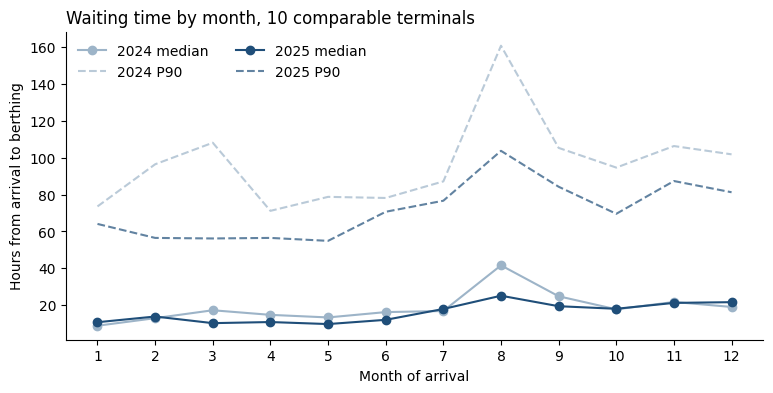

In [4]:
# 4 — Seasonality: monthly wait profile, 2024 vs 2025 (10 comparable terminals)
mdf["half"] = np.where(mdf["month"] <= 6, "H1", "H2")
mdf["peak_aug_nov"] = mdf["month"].between(8, 11)

monthly = (mdf.groupby(["month", "arr_year"])["wait_h"]
           .agg(n="size", median="median", p90=lambda s: s.quantile(0.9)).unstack("arr_year").round(1))
print("Wait by month of arrival (h):")
print(monthly.to_string(), "\n")

print("Median wait by half-year (h):")
print(mdf.groupby(["arr_year", "half"])["wait_h"].median().unstack().round(1).to_string(), "\n")

print("Median wait, Aug–Nov vs rest of the year (h):")
print(mdf.groupby(["arr_year", "peak_aug_nov"])["wait_h"].median().unstack()
      .rename(columns={True: "Aug-Nov", False: "Other months"}).round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for y, c in [(2024, "#9db4c8"), (2025, "#1f4e79")]:
    ax.plot(monthly.index, monthly[("median", y)], "o-", color=c, label=f"{y} median")
    ax.plot(monthly.index, monthly[("p90", y)], "--", color=c, alpha=0.7, label=f"{y} P90")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month of arrival")
ax.set_ylabel("Hours from arrival to berthing")
ax.set_title("Waiting time by month, 10 comparable terminals", loc="left")
ax.legend(frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [5]:
# 5 — The August peak: demand or weather? Terminal, zone, arrivals and queue by month
mdf["zone"] = np.select(
    [mdf["terminal"].str.contains("Santos"),
     mdf["terminal"].str.contains("Paranaguá|Itapoá|Portonave|Rio Grande")],
    ["Santos", "South"], default="North/Northeast")

aug = (mdf.assign(is_aug=mdf["month"] == 8)
       .groupby(["terminal", "arr_year", "is_aug"])["wait_h"].median().unstack("is_aug"))
aug.columns = ["other_months", "august"]
aug["aug_minus_other_h"] = aug["august"] - aug["other_months"]
print("August vs other months, median wait by terminal (h):")
print(aug["aug_minus_other_h"].unstack("arr_year").round(1).sort_values(2025, ascending=False).to_string(), "\n")

print("Median wait by zone and month (h):")
print(mdf.groupby(["zone", "arr_year", "month"])["wait_h"].median().unstack("month").round(0).to_string(), "\n")

arrivals = mdf.groupby(["arr_year", "month"]).agg(
    calls=("call_id", "size"), mean_queue=("q_waiting", "mean"), median_wait=("wait_h", "median"))
arrivals["wait_per_queued_ship_h"] = arrivals["median_wait"] / arrivals["mean_queue"].clip(lower=0.1)
print("Arrivals, queue and wait by month:")
print(arrivals.unstack("arr_year").round(1).to_string())

August vs other months, median wait by terminal (h):
arr_year                                                                                         2024  2025
terminal                                                                                                   
Paranaguá | TCP                                                                                  73.5  44.8
Paranaguá | CAIS PÚBLICO                                                                         26.6  27.1
Santos | Cais da BTP (SSZ 41) - Privativo                                                        34.7  25.9
Santos | Cais da Santos Brasil (SSZ 16) - Privativo                                              30.1   7.3
Porto Itapoá Terminais Portuários | Porto Itapoá Terminais Portuários                            20.3   7.0
DP World Santos | DP World Santos                                                                75.9   2.7
Rio Grande | Cais Tecon Rio Grande S.A.                                            

In [6]:
# 6 — Shared nautical access: does non-container traffic in Santos and Paranaguá move with container waits?
RAW = BASE / "data" / "raw"
allc = pd.concat([pd.read_csv(RAW / f"antaq_{y}_atracacao.txt", sep=";", encoding="utf-8-sig", dtype=str,
                              usecols=["IDAtracacao", "Complexo Portuário", "Data Chegada"]) for y in (2024, 2025)])
allc["ts_arrival"] = pd.to_datetime(allc["Data Chegada"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
allc = allc[allc["ts_arrival"].between("2024-01-01", "2025-11-30 23:59")]   # full months only
allc["ym"] = allc["ts_arrival"].dt.to_period("M")
allc["is_container"] = allc["IDAtracacao"].astype(int).isin(set(calls["call_id"]))

COMPLEXES = ["Santos", "Paranaguá - Antonina"]
cx = allc[allc["Complexo Portuário"].isin(COMPLEXES)]
other = cx[~cx["is_container"]].groupby(["Complexo Portuário", "ym"]).size().rename("non_container_calls")

mdf["complex"] = np.select([mdf["terminal"].str.contains("Santos"), mdf["terminal"].str.contains("Paranaguá")],
                           COMPLEXES, default="Other")
mdf["ym"] = mdf["ts_arrival"].dt.to_period("M")
cw = (mdf[mdf["complex"] != "Other"].groupby(["complex", "ym"])["wait_h"].median()
      .rename("container_median_wait"))
cw.index = cw.index.set_names(["Complexo Portuário", "ym"])

j = pd.concat([other, cw], axis=1).dropna()
for c, g in j.groupby(level=0):
    rho = g["non_container_calls"].corr(g["container_median_wait"], method="spearman")
    print(f"{c}: Spearman {rho:.2f} over {len(g)} months")

prof_m = j.reset_index()
prof_m["month"] = prof_m["ym"].dt.month
print("\nAverage by calendar month (both years):")
print(prof_m.groupby(["Complexo Portuário", "month"])[["non_container_calls", "container_median_wait"]]
      .mean().unstack(0).round(0).to_string())

Paranaguá - Antonina: Spearman 0.38 over 23 months
Santos: Spearman -0.01 over 23 months

Average by calendar month (both years):
                    non_container_calls        container_median_wait       
Complexo Portuário Paranaguá - Antonina Santos  Paranaguá - Antonina Santos
month                                                                      
1                                 130.0  292.0                  12.0   12.0
2                                 124.0  330.0                  13.0   18.0
3                                 130.0  368.0                  23.0   11.0
4                                 128.0  301.0                  12.0   12.0
5                                 166.0  340.0                  11.0   17.0
6                                 162.0  342.0                  20.0   15.0
7                                 169.0  341.0                  27.0   23.0
8                                 168.0  353.0                  58.0   41.0
9                                 

In [7]:
# 7 — Which operator waits longest? Raw ranking vs same-terminal, same-month (and same-queue) comparison
mdf["log_w"] = np.log1p(mdf["wait_h"])
mdf["q_band"] = mdf["q_waiting"].clip(upper=3)
mdf["week"] = mdf["ts_arrival"].dt.to_period("W")

def excess(df, keys, min_cell=5):
    g = df.groupby(keys)["log_w"]
    return (df["log_w"] - g.transform("median")).where(g.transform("size") >= min_cell)

mdf["ex_tm"] = excess(mdf, ["terminal", "ym"])                 # same terminal, same month
mdf["ex_tmq"] = excess(mdf, ["terminal", "ym", "q_band"])      # ... and same queue on arrival

rng = np.random.default_rng(42)
def boot_ci(x, weeks, n_boot=1000):
    d = pd.DataFrame({"x": x, "w": weeks}).dropna()
    groups = [g["x"].to_numpy() for _, g in d.groupby("w")]
    k = len(groups)
    meds = [np.median(np.concatenate([groups[j] for j in rng.integers(0, k, k)])) for _ in range(n_boot)]
    return np.percentile(meds, [2.5, 97.5])

def ranking(df, by, min_calls=100):
    rows = []
    for key, d in df.dropna(subset=[by]).groupby(by):
        if len(d) < min_calls:
            continue
        lo, hi = boot_ci(d["ex_tm"], d["week"])
        pct = lambda v: 100 * (np.exp(v) - 1)
        rows.append({by: key, "calls": len(d), "raw_median_h": d["wait_h"].median(),
                     "vs_same_terminal_month_%": pct(d["ex_tm"].median()),
                     "CI_low_%": pct(lo), "CI_high_%": pct(hi),
                     "vs_same_terminal_month_queue_%": pct(d["ex_tmq"].median())})
    return pd.DataFrame(rows).set_index(by).sort_values("vs_same_terminal_month_%", ascending=False).round(1)

y25 = mdf[mdf["arr_year"] == 2025]
print("2025 — by vessel operator:")
print(ranking(y25, "Armador_Operador").to_string(), "\n")
print("2024 + 2025 — by vessel operator (2024 coverage is lower):")
print(ranking(mdf, "Armador_Operador").to_string(), "\n")
print("2025 — by alliance:")
print(ranking(y25, "Aliança").to_string(), "\n")

top_t = mdf["terminal"].value_counts().head(6).index
mix = pd.crosstab(y25["Armador_Operador"], y25["terminal"], normalize="index")[top_t] * 100
mix.columns = [c.split(" | ")[0][:22] + " | " + c.split(" | ")[-1][:18] for c in mix.columns]
print("2025 — where each operator calls (% of its calls, top 6 terminals):")
print(mix.loc[mix.index.isin(ranking(y25, "Armador_Operador").index)].round(0).to_string())

2025 — by vessel operator:
                  calls  raw_median_h  vs_same_terminal_month_%  CI_low_%  CI_high_%  vs_same_terminal_month_queue_%
Armador_Operador                                                                                                    
MSC                 866          23.4                      38.6      21.9       51.7                            16.1
COSCO               216          24.1                      30.5       2.0       82.3                            35.7
HMM                 120          18.8                      18.4     -16.3       48.5                             0.0
Múltiplos           506          16.6                       5.9      -6.9       17.7                             0.0
CMA CGM             376          15.1                       1.3      -8.8       20.0                             2.1
ONE Line            117          19.9                       1.1      -7.3       55.3                             0.0
Hapag-Lloyd         374          14.5

In [8]:
# 8 — Vessel size: does class explain the operator gap, and do big ships pay more in the peak season?
CLASS_ORDER = ["Feeder / Sub-Panamax", "Panamax", "Neo-Panamax", "Large Post-Panamax", "Ultra Large (ULCS)"]
pct = lambda v: 100 * (np.exp(v) - 1)

print("2025 — by vessel class (vs other ships at the same terminal, same month):")
print(ranking(y25, "Classe_Navio", min_calls=50).reindex(CLASS_ORDER).to_string(), "\n")

oc = (y25.dropna(subset=["Armador_Operador", "Classe_Navio"])
      .groupby(["Armador_Operador", "Classe_Navio"])
      .agg(calls=("ex_tm", "size"), excess=("ex_tm", "median")))
oc = oc[oc["calls"] >= 30]
print("2025 — operator within the same class: % vs same terminal & month (cells with >= 30 calls):")
print(pct(oc["excess"]).unstack("Classe_Navio").reindex(columns=CLASS_ORDER).round(0).to_string())
print("\nCalls per cell:")
print(oc["calls"].unstack("Classe_Navio").reindex(columns=CLASS_ORDER).to_string(), "\n")

pk = (mdf.dropna(subset=["Classe_Navio"])
      .groupby(["Classe_Navio", "peak_aug_nov"])
      .agg(calls=("wait_h", "size"), median_h=("wait_h", "median"), excess=("ex_tm", "median")))
tab_pk = pk["median_h"].unstack("peak_aug_nov").rename(columns={False: "other_months_h", True: "aug_nov_h"})
tab_pk["penalty_h"] = tab_pk["aug_nov_h"] - tab_pk["other_months_h"]
tab_pk["penalty_%"] = 100 * (tab_pk["aug_nov_h"] / tab_pk["other_months_h"] - 1)
ex_pk = pct(pk["excess"]).unstack("peak_aug_nov").rename(columns={False: "vs_peers_other_%", True: "vs_peers_aug_nov_%"})
calls_pk = pk["calls"].unstack("peak_aug_nov").rename(columns={False: "calls_other", True: "calls_aug_nov"})
print("2024 + 2025 — peak-season penalty by class:")
print(pd.concat([tab_pk, ex_pk, calls_pk], axis=1).reindex(CLASS_ORDER).round(1).to_string())

2025 — by vessel class (vs other ships at the same terminal, same month):
                      calls  raw_median_h  vs_same_terminal_month_%  CI_low_%  CI_high_%  vs_same_terminal_month_queue_%
Classe_Navio                                                                                                            
Feeder / Sub-Panamax    406          14.9                       7.3      -2.5       23.1                             5.7
Panamax                 667          12.1                      -9.3     -22.7        0.1                            -6.5
Neo-Panamax            1855          13.8                      -3.0      -8.8        0.0                            -0.3
Large Post-Panamax      837          19.2                       7.7       0.2       19.3                             4.1
Ultra Large (ULCS)      100          27.2                      65.4       6.3      137.6                            90.5 

2025 — operator within the same class: % vs same terminal & month (cells with

In [9]:
# 9 — Spread of the wait by class and operator (Q10), and a check on the peak-season result
def spread(d):
    q = d["wait_h"].quantile
    return pd.Series({"calls": len(d), "median_h": q(0.5), "IQR_h": q(0.75) - q(0.25),
                      "P90_h": q(0.9), "std_h": d["wait_h"].std()})

sp = (y25.dropna(subset=["Armador_Operador", "Classe_Navio"])
      .groupby(["Classe_Navio", "Armador_Operador"]).apply(spread, include_groups=False))
sp = sp[sp["calls"] >= 30].reindex(CLASS_ORDER, level=0)
print("2025 — spread of the wait by class and operator (cells with >= 30 calls):")
print(sp.round(1).to_string(), "\n")

lpp = mdf[mdf["Classe_Navio"] == "Large Post-Panamax"]
print("Large Post-Panamax — wait vs peers at the same terminal & month, 2024 + 2025:")
for label, d in [("all operators", lpp), ("without MSC", lpp[lpp["Armador_Operador"] != "MSC"])]:
    for peak, name in [(False, "other months"), (True, "Aug-Nov")]:
        g = d[d["peak_aug_nov"] == peak]
        lo, hi = boot_ci(g["ex_tm"], g["week"])
        print(f"  {label:14s} {name:12s}: {pct(g['ex_tm'].median()):6.1f}%  "
              f"[{pct(lo):6.1f}%; {pct(hi):6.1f}%]  n={len(g)}")

2025 — spread of the wait by class and operator (cells with >= 30 calls):
                                       calls  median_h  IQR_h  P90_h  std_h
Classe_Navio         Armador_Operador                                      
Feeder / Sub-Panamax CMA CGM            69.0      10.7   34.1   73.1   35.8
                     Maersk            151.0      10.7   24.4   55.8   36.7
                     Múltiplos         105.0      19.8   38.0   79.7   37.7
Panamax              CMA CGM            47.0       6.1   13.4   51.2   24.6
                     COSCO              58.0      15.6   31.8   78.6   48.5
                     HMM                41.0      14.6   40.2   62.3   28.9
                     Hapag-Lloyd       117.0      10.7   20.9   35.5   17.2
                     Maersk            162.0      11.2   24.8   59.7   31.4
                     Múltiplos         178.0      11.4   20.7   49.4   31.9
                     ONE Line           44.0      29.1   43.4   90.8   35.1
Neo-Panamax   

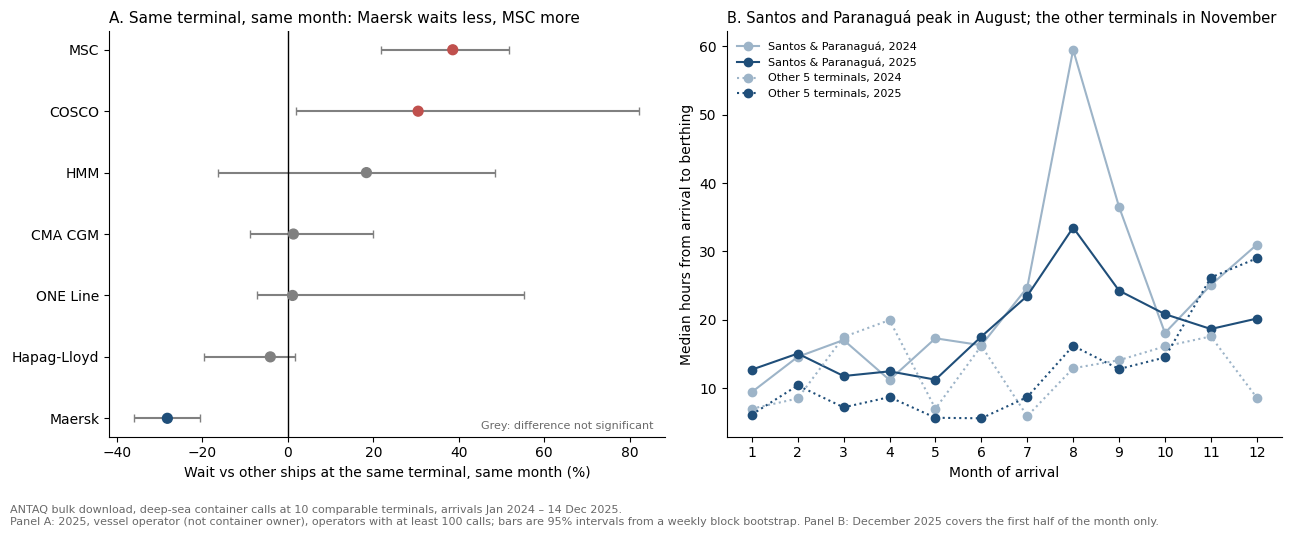

In [10]:
# 10 — Figure (fig10): who waits longer, and when
FIG_DIR = BASE / "outputs" / "figures"
rng = np.random.default_rng(42)   # same bootstrap draws as in block 7
rk = (ranking(y25, "Armador_Operador").drop(index=["Múltiplos"], errors="ignore")
      .sort_values("vs_same_terminal_month_%"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — colour only where the 95% interval excludes zero
yy = np.arange(len(rk))
est = rk["vs_same_terminal_month_%"]
sig_color = np.where(rk["CI_low_%"] > 0, "#c0504d", np.where(rk["CI_high_%"] < 0, "#1f4e79", "grey"))
ax1.errorbar(est, yy, xerr=[est - rk["CI_low_%"], rk["CI_high_%"] - est],
             fmt="none", ecolor="grey", capsize=3)
ax1.scatter(est, yy, color=sig_color, zorder=3, s=50)
ax1.axvline(0, color="black", lw=1)
ax1.set_yticks(yy, rk.index)
ax1.set_xlabel("Wait vs other ships at the same terminal, same month (%)")
ax1.set_title("A. Same terminal, same month: Maersk waits less, MSC more", loc="left", fontsize=11)
ax1.text(0.98, 0.02, "Grey: difference not significant", transform=ax1.transAxes,
         ha="right", fontsize=8, color="dimgrey")

# Panel B — monthly median wait, Santos & Paranaguá vs the other 5 terminals
grp = np.where(mdf["complex"] != "Other", "Santos & Paranaguá", "Other 5 terminals")
mm = mdf.assign(grp=grp).groupby(["grp", "arr_year", "month"])["wait_h"].median()
for g, ls in [("Santos & Paranaguá", "-"), ("Other 5 terminals", ":")]:
    for y, c in [(2024, "#9db4c8"), (2025, "#1f4e79")]:
        s = mm.loc[(g, y)]
        ax2.plot(s.index, s.values, ls, marker="o", color=c, label=f"{g}, {y}")
ax2.set_xticks(range(1, 13))
ax2.set_xlabel("Month of arrival")
ax2.set_ylabel("Median hours from arrival to berthing")
ax2.set_title("B. Santos and Paranaguá peak in August; the other terminals in November", loc="left", fontsize=10.5)
ax2.legend(frameon=False, fontsize=8)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.06,
         "ANTAQ bulk download, deep-sea container calls at 10 comparable terminals, arrivals Jan 2024 – 14 Dec 2025.\n"
         "Panel A: 2025, vessel operator (not container owner), operators with at least 100 calls; bars are 95% intervals "
         "from a weekly block bootstrap. Panel B: December 2025 covers the first half of the month only.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig10_wait_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Deep-sea container calls at 10 comparable terminals, arrivals January 2024 to 14 December 2025. Waits come from ANTAQ's arrival and berthing timestamps. Carriers and vessel classes come from the vessel table (93% of 2025 TEU, 71% of 2024).

- **2024 was worse than 2025.** Median wait 17.6 h vs 15.2 h, driven by heavy congestion at DP World Santos and Portonave in 2024 (medians of 43 h and 48 h).
- **The second half is worse every year.** H1 to H2: +8.3 h in 2024, +9.0 h in 2025. The rise reported for 2025 in the main notebook is seasonal, not a one-off.
- **Santos and Paranaguá peak in August, both years; the other terminals in November** (and December in 2025). August brings fewer arrivals, not more, yet the longest and slowest queue of the year: berthing capacity drops. Non-container traffic does not explain it in Santos and only weakly in Paranaguá (Spearman 0.38, 23 months). Weather and terminal-side constraints remain untested.
- **Same terminal, same month: Maersk waits about 28% less than other ships, MSC about 39% more** (95% intervals −36% to −21% and +22% to +52%). The gap holds within the same vessel class (Neo-Panamax: Maersk −32%, MSC +35%, 600+ calls each) and partly survives comparing ships that found the same queue on arrival. By alliance: Gemini −25%, Ocean Alliance +20%.
- **Vessel size matters less than terminal and month.** Ultra Large ships wait longer, but in 2025 they are all COSCO, so class and carrier cannot be separated. Large ships wait more hours in August–November, but relative to other ships at the same terminal and month there is no extra peak-season penalty once MSC is taken out.
- **Maersk is also the most predictable.** Neo-Panamax P90: 38 h for Maersk vs 77 h for MSC.

## Limitations

1. **Operator, not container owner.** Vessels are assigned to their operator; on shared services, partners' boxes count under the operator.
2. **Association, not cause.** The operator gap may come from berth-window agreements, rotation design or a policy of arriving early. The data cannot tell them apart.
3. **Two years.** Enough to see a repeated seasonal pattern, not to call it permanent.
4. **Alliances and services are taken from 2026 schedules.**
5. **Wait is time from logged arrival to berthing.** It includes deliberate early arrivals, not only congestion.